# Dense Noise

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
import sys

sys.path.append(str(Path('../..').parent))

from utils import plot_stim

In [3]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [4]:
crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [5]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [6]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['RGC_Noise_60Hz_10um_pixels.mp4',
 'RGC_Noise_60Hz_10um_pixels.npz',
 'RGC_Noise_60Hz_10um_pixels_mark.npz',
 'RGC_Noise_shifty_b10um_60Hz_10um_pixels.mp4',
 'RGC_Noise_shifty_b10um_60Hz_10um_pixels.npz',
 'RGC_Noise_shifty_b10um_60Hz_10um_pixels_mark.npz']

In [7]:
noise_name = 'noise'
noise_file = 'RGC_Noise_60Hz_10um_pixels.npz'
noise_mark_file = 'RGC_Noise_60Hz_10um_pixels_mark.npz'

shifty_name = 'shifty'
shifty_file = 'RGC_Noise_shifty_b10um_60Hz_10um_pixels.npz'
shifty_mark_file = 'RGC_Noise_shifty_b10um_60Hz_10um_pixels_mark.npz'

In [8]:
# We downsample to reduce the size of the stimulus without losing any (!) information, since the frames are updated at 5 Hz.
# Because of an implementation detail, shifty noise is updated at 20 Hz, so we just downsample both to 20 Hz.

target_freq = 20
source_freq = 60

t_downsample = int(source_freq/target_freq)  
t_downsample

3

## Standard dense noise

In [9]:
noise_mark = np.load(os.path.join(qdspy_export_dir, noise_mark_file))['data']
noise_mark = np.append(noise_mark[:-1] & (~noise_mark[1:]), False)
i0 = np.argmax(noise_mark > 0)
noise_mark = noise_mark[i0::t_downsample]
noise_mark.shape, np.sum(noise_mark)

((6020,), np.int64(1500))

In [10]:
noise = np.load(os.path.join(qdspy_export_dir, noise_file))['data']
noise = np.round(np.mean(noise, axis=-1)).astype(int)
assert np.allclose(noise[i0], noise[np.any(noise>0, axis=(1,2))][0])
noise = noise[i0::t_downsample, :, :]
noise.shape

(6020, 120, 120)

## Shifty dense noise

In [11]:
shifty_mark = np.load(os.path.join(qdspy_export_dir, shifty_mark_file))['data']
shifty_mark = np.append(shifty_mark[:-1] & (~shifty_mark[1:]), False)
i0 = np.argmax(shifty_mark > 0)
shifty_mark = shifty_mark[i0::t_downsample]
shifty_mark.shape, np.sum(shifty_mark)

((6020,), np.int64(1500))

In [12]:
shifty = np.load(os.path.join(qdspy_export_dir, shifty_file))['data']
shifty = np.round(np.mean(shifty, axis=-1)).astype(int)
assert np.allclose(shifty[i0], shifty[np.any(shifty>0, axis=(1,2))][0])
shifty = shifty[i0::t_downsample, :, :]
shifty.shape

(6020, 120, 120)

## Compare

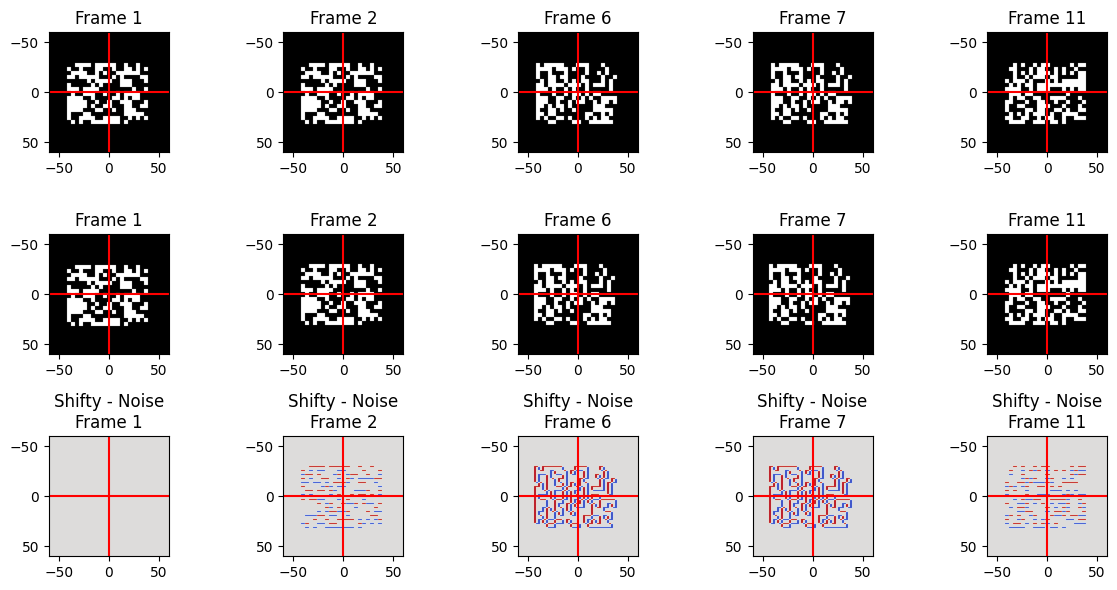

In [13]:
# Note that this stimulus is not properly centered due to an implementation detail in QDSpy.
# The red lines indicate the center of the stimulus as it was displayed which is not the center of the actual checkerboard pattern.
# The stimulus, as it was displayed, is shifted half a pixel in both dimensions.
# This really only matters when you want to precisely align the stimulus with the receptive field of a neuron.

h, w = noise.shape[1:3]
frames = [0, 1, 5, 6, 10]
fig, axs = plt.subplots(3, len(frames), figsize=(12, 6))

for j, frame in enumerate(frames):
    for i, stim in enumerate([noise, shifty]):
        axs[i, j].imshow(stim[frame], vmin=0, vmax=255, interpolation='none', cmap='gray', extent=(-w/2, w/2, h/2, -h/2))
        axs[i, j].axhline(0, color='r')
        axs[i, j].axvline(0, color='r')
        axs[i, j].set(title=f'Frame {frame + 1}')

    axs[2, j].imshow(shifty[frame] - noise[frame], vmin=-255, vmax=255, interpolation='none', cmap='coolwarm', extent=(-w/2, w/2, h/2, -h/2))
    axs[2, j].axhline(0, color='r')
    axs[2, j].axvline(0, color='r')
    axs[2, j].set(title=f'Shifty - Noise\nFrame {frame + 1}')
plt.tight_layout()
plt.show()

In [14]:
time_stim = np.arange(noise.shape[0]) * t_downsample/60.

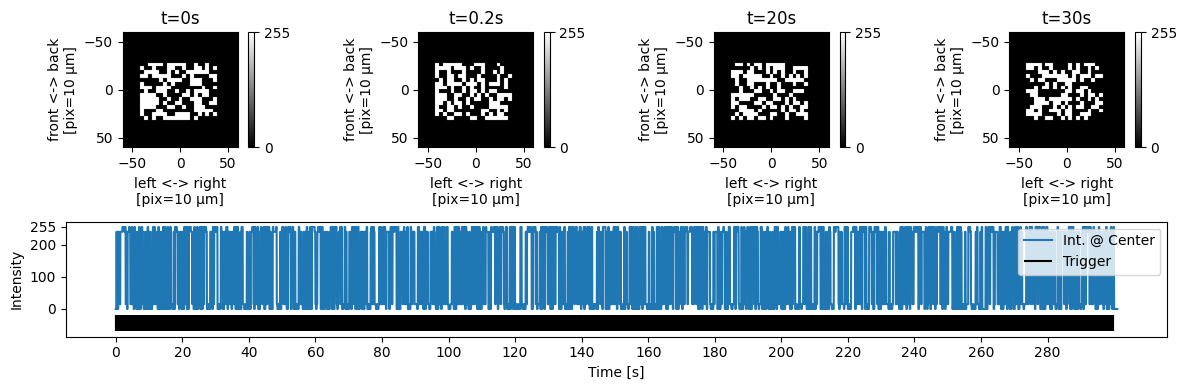

In [15]:
t_s_plot = (0, 1/5, 20, 30)

plot_stim(noise, noise_mark, time_stim, t_s_plot=t_s_plot);

In [16]:
noise_setup1 = np.flip(np.rot90(noise, k=1, axes=(1, 2)), axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
shifty_setup1 = np.flip(np.rot90(shifty, k=1, axes=(1, 2)), axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]

noise_setup3 = np.rot90(noise, k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
shifty_setup3 = np.rot90(shifty, k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]

In [17]:
stim_dict = {
    (noise_name, '1'): noise_setup1, (shifty_name, '1'): shifty_setup1,
    (noise_name, '3'): noise_setup3, (shifty_name, '3'): shifty_setup3}

Plotting noise setup 1


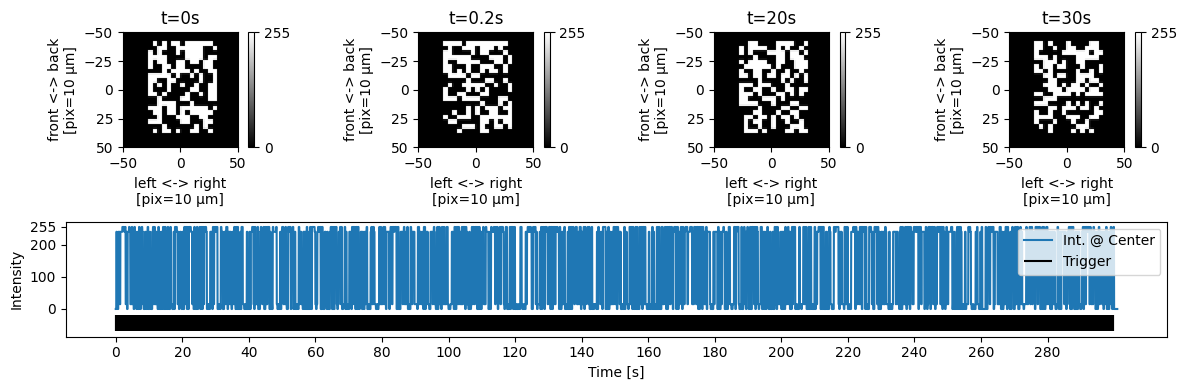

Plotting shifty setup 1


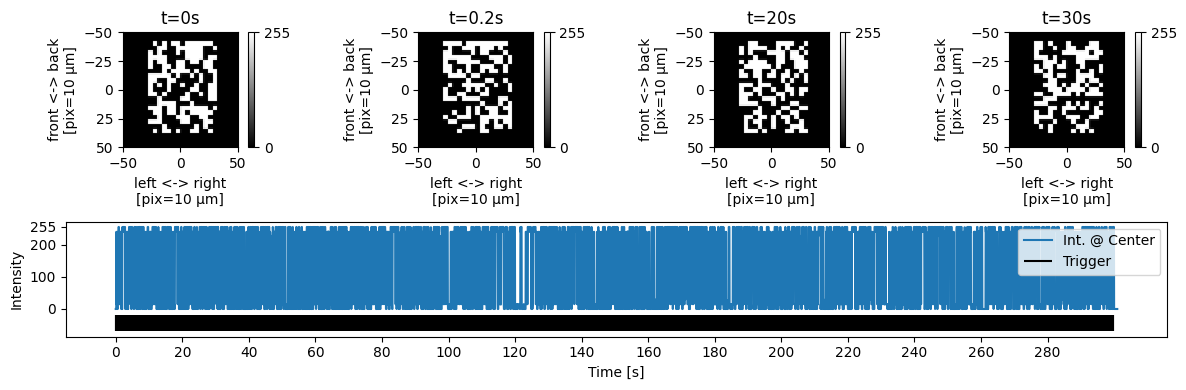

Plotting noise setup 3


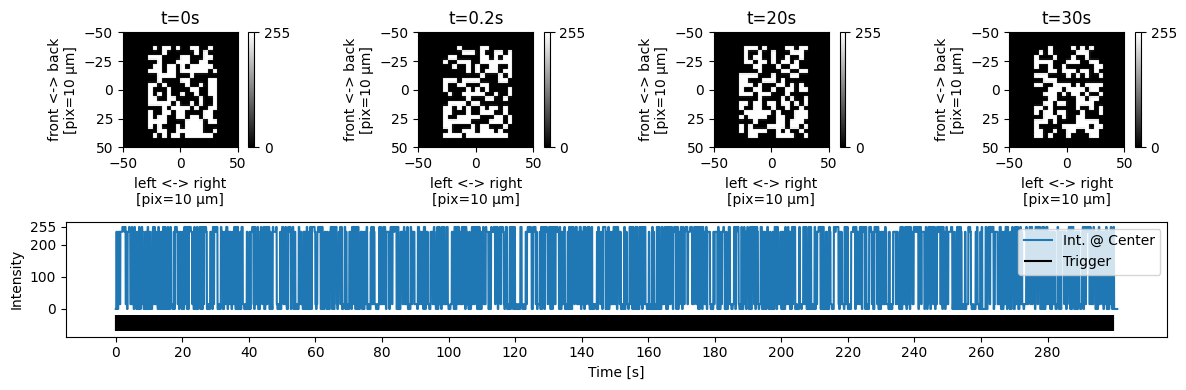

Plotting shifty setup 3


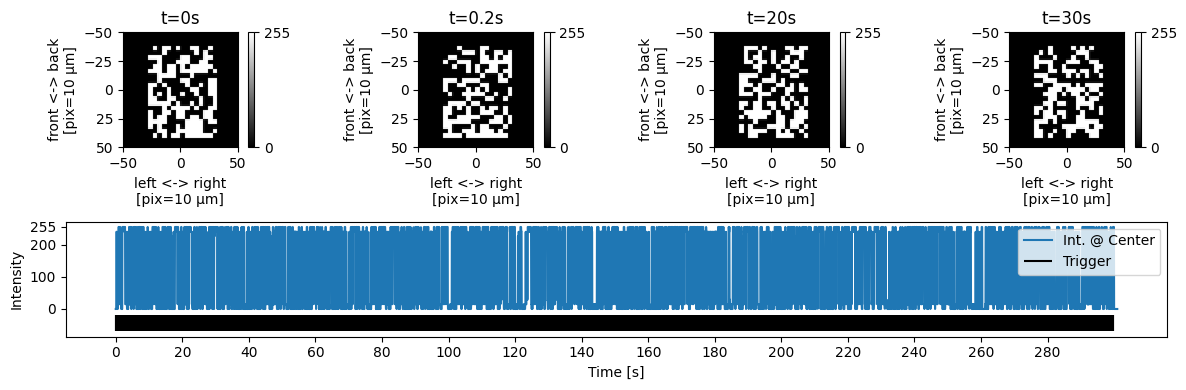

In [18]:
for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name} setup {setup}')
    fig, axs = plot_stim(stim, noise_mark, time_stim, t_s_plot=t_s_plot)
    plt.savefig(os.path.join(out_dir, f'{name}_setup{setup}.pdf'), bbox_inches='tight')
    plt.show()

In [19]:
for (name, setup), stim in stim_dict.items():
    
    assert np.all(stim.astype(np.uint8) == stim)

    np.savez_compressed(
        os.path.join(out_dir, f'{name}_setup{setup}_movie_and_trigger'),
        stimulus=stim.astype(np.uint8),
        time=time_stim.astype(np.float32),
        trigger=noise_mark,
    )